In [17]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
pip install aif360


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 5.2 MB/s eta 0:00:00


In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric


In [11]:
# df.to_csv('/content/drive/MyDrive/python/cleanedDataset.csv', index=False)

NameError: name 'df' is not defined

In [19]:
df=pd.read_csv('/content/drive/MyDrive/python/cleanedDataset.csv')

In [13]:
df.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,JobInvolvement,MaritalStatus,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear
0,41,1,2,1,2,0,3,2,3,8,0
1,49,0,1,8,1,1,2,1,4,10,3
2,37,1,2,2,2,1,2,2,3,7,3
3,33,0,1,3,4,0,3,1,3,8,3
4,27,0,2,2,1,1,3,1,3,6,3


# **Modeling:**

In [30]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

y = df['Should_hire']
X = df.drop('Should_hire', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

Before SMOTEENN: Counter({0: 863, 1: 166})
After SMOTEENN: Counter({0: 863, 1: 863})


# Logistique regression:

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/Logistique_regression.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.22      0.57      0.32        56
           1       0.92      0.70      0.80       385

    accuracy                           0.68       441
   macro avg       0.57      0.64      0.56       441
weighted avg       0.83      0.68      0.73       441



Gender

In [ ]:
from aif360.datasets import BinaryLabelDataset

test_df = X_test.copy()
test_df['Should_hire'] = y_test
test_df['predicted'] = y_pred

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)


In [ ]:
from aif360.metrics import BinaryLabelDatasetMetric

privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]
metric = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)

print("Disparate Impact:", metric.disparate_impact())
print("SPD:", metric.statistical_parity_difference())


Disparate Impact: 0.9862937062937062
SPD: -0.009193245778611692


## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias



Age

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8280701754385965
Statistical Parity Diff (Age): -0.1289473684210526


## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias



Marital Status

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 1.0
Statistical Parity Diff (Age): 0.0


## **Interpretation:**

DI < 0.8 → strong evidence of bias

0.8 ≤ DI ≤ 1.25 → generally acceptable

DI ≈ 1 → ideal fairness

|SPD| < 0.05 → very small bias

|SPD| > 0.1 → concerning bias



BusinessTravel

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.0564841498559077
Statistical Parity Diff (Age): 0.03605371267398361


Distance from home

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.0542936288088642
Statistical Parity Diff (Age): 0.03577730453300887


Education

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7588151064972256
Statistical Parity Diff (Age): -0.19260088617847448


training times

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7176271186440678
Statistical Parity Diff (Age): -0.24342489772063114


years of working

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.6905263157894737
Statistical Parity Diff (Age): -0.2578947368421053


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 3:
        return 0
    else:
        return 1

test_df['envolvementGroup'] = test_df['JobInvolvement'].apply(training_bin)

protected_attribute = 'envolvementGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.3905401459854015
Statistical Parity Diff (Age): -0.5012005378409528


# Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/random_forest.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

In [ ]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.31      0.43      0.36        56
           1       0.91      0.86      0.89       385

    accuracy                           0.80       441
   macro avg       0.61      0.64      0.62       441
weighted avg       0.84      0.80      0.82       441



In [ ]:
from aif360.datasets import BinaryLabelDataset

test_df = X_test.copy()
test_df['Should_hire'] = y_test
test_df['predicted'] = y_pred



Gender

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]# Female

metric_knn = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)
print("Disparate Impact (Age):", metric_knn.disparate_impact())
print("Statistical Parity Diff (Age):", metric_knn.statistical_parity_difference())

Disparate Impact (Age): 0.8985486211901307
Statistical Parity Diff (Age): -0.0874296435272045


Age

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8518902891030393
Statistical Parity Diff (Age): -0.1348178137651822


Marital status

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 1.003609022556391
Statistical Parity Diff (Age): 0.002965159377316562


BusinessTravel

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.2419419197517179
Statistical Parity Diff (Age): 0.1673002636581028


DistanceFromHome

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.1307619228576857
Statistical Parity Diff (Age): 0.104685123212656


Education

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8054635761589405
Statistical Parity Diff (Age): -0.1847396255181285


Training times

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8979791395045632
Statistical Parity Diff (Age): -0.09146697837521922


years of working

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7861533027198869
Statistical Parity Diff (Age): -0.20425101214574903


job envolvement

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 3:
        return 0
    else:
        return 1

test_df['envolvementGroup'] = test_df['JobInvolvement'].apply(training_bin)

protected_attribute = 'envolvementGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7533062191935788
Statistical Parity Diff (Age): -0.21991452170572423


# SVM

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

svm_model.fit(X_train, y_train)


LinearSVC(max_iter=5000, random_state=42)

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/SVM.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

In [ ]:
y_pred_svm = svm_model.predict(X_test)


In [ ]:
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.21      0.55      0.30        56
           1       0.91      0.69      0.79       385

    accuracy                           0.68       441
   macro avg       0.56      0.62      0.55       441
weighted avg       0.82      0.68      0.73       441



In [ ]:
test_df = X_test.copy()
test_df['Should_hire'] = y_test
test_df['predicted'] = y_pred_svm

Gender

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]

metric = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)
print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.971002331002331
Statistical Parity Diff (Age): -0.01944965603502191


Age

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8304900181488204
Statistical Parity Diff (Age): -0.12604588394062077


Marital status

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 0.986842105263158
Statistical Parity Diff (Age): -0.00877192982456132


job envolvement

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.04745437079731
Statistical Parity Diff (Age): 0.0302900239131767


BusinessTravel

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.04745437079731
Statistical Parity Diff (Age): 0.0302900239131767


Distance from home

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.0428935775562254
Statistical Parity Diff (Age): 0.028141162153939803


education

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7397114474929045
Statistical Parity Diff (Age): -0.209728905617228


Training

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7240036646816308
Statistical Parity Diff (Age): -0.2347555036041301


Totale of working years

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.6727199678585777
Statistical Parity Diff (Age): -0.2748313090418354


job Involvement

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 3:
        return 0
    else:
        return 1

test_df['envolvementGroup'] = test_df['JobInvolvement'].apply(training_bin)

protected_attribute = 'envolvementGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.3936896632917353
Statistical Parity Diff (Age): -0.4946215904725317


#  Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


GaussianNB()

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/GaussianNB.pkl', 'wb') as file:
    pickle.dump(nb_model, file)

In [ ]:
y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.15      0.96      0.26        56
           1       0.97      0.19      0.32       385

    accuracy                           0.29       441
   macro avg       0.56      0.58      0.29       441
weighted avg       0.87      0.29      0.31       441



In [ ]:
test_df = X_test.copy()
test_df['Should_hire'] = y_test
test_df['predicted'] = y_pred_nb

Gender

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]

metric_knn = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)
print("Disparate Impact (Age):", metric_knn.disparate_impact())
print("Statistical Parity Diff (Age):", metric_knn.statistical_parity_difference())

Disparate Impact (Age): 1.076923076923077
Statistical Parity Diff (Age): 0.01282051282051283


Age

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7945670628183362
Statistical Parity Diff (Age): -0.04082321187584345


Marital Status

In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 0.886302294197031
Statistical Parity Diff (Age): -0.02081788979490981


Business Travel

In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8728786423310918
Statistical Parity Diff (Age): -0.024342387638727092


Distance from home

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.2140350877192982
Statistical Parity Diff (Age): 0.035260115606936426


Education

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.9972406181015452
Statistical Parity Diff (Age): -0.00047644004002098117


Training

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7919020715630884
Statistical Parity Diff (Age): -0.04305474381453342


Working years

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.713237639553429
Statistical Parity Diff (Age): -0.0606612685560054


Job envolvement

In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 3:
        return 0
    else:
        return 1

test_df['envolvementGroup'] = test_df['JobInvolvement'].apply(training_bin)

protected_attribute = 'envolvementGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7396593673965937
Statistical Parity Diff (Age): -0.04881386861313869


# KNN

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'
)

knn_model.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=7, weights='distance')

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/KNN.pkl', 'wb') as file:
    pickle.dump(knn_model, file)

In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.19      0.46      0.27        56
           1       0.90      0.71      0.80       385

    accuracy                           0.68       441
   macro avg       0.55      0.59      0.53       441
weighted avg       0.81      0.68      0.73       441



In [ ]:
test_df = X_test.copy()
test_df['Should_hire'] = y_test
test_df['predicted'] = y_pred_knn

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]

metric_knn = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)
print("Disparate Impact (Age):", metric_knn.disparate_impact())
print("Statistical Parity Diff (Age):", metric_knn.statistical_parity_difference())

Disparate Impact (Age): 0.8880103137086378
Statistical Parity Diff (Age): -0.08148843026891806


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.9043478260869564
Statistical Parity Diff (Age): -0.0705128205128206


In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 1.0308529945553537
Statistical Parity Diff (Age): 0.021003212255992


In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.4870317002881845
Statistical Parity Diff (Age): 0.24351585014409227


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.1460072595281305
Statistical Parity Diff (Age): 0.09790082141770606


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7604376619637202
Statistical Parity Diff (Age): -0.19819905664872073


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8405797101449275
Statistical Parity Diff (Age): -0.12643678160919547


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7569078947368422
Statistical Parity Diff (Age): -0.19946018893387307


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 3:
        return 0
    else:
        return 1

test_df['envolvementGroup'] = test_df['JobInvolvement'].apply(training_bin)

protected_attribute = 'envolvementGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7493917274939172
Statistical Parity Diff (Age): -0.18795620437956206


# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [ ]:
import pickle

with open('/content/drive/MyDrive/python/gb_model.pkl', 'wb') as file:
    pickle.dump(gb_model, file)

In [ ]:
y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.27      0.48      0.35        56
           1       0.91      0.81      0.86       385

    accuracy                           0.77       441
   macro avg       0.59      0.65      0.60       441
weighted avg       0.83      0.77      0.79       441



In [ ]:
test_df = X_test.copy()
test_df['Should_hire'] = y_test
test_df['predicted'] = y_pred_gb

In [ ]:

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)

metric_gb = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)

print("GB Disparate Impact:", metric_gb.disparate_impact())
print("GB SPD:", metric_gb.statistical_parity_difference())


GB Disparate Impact: 0.9445364891518737
GB SPD: -0.04396497811131961


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8995512035903713
Statistical Parity Diff (Age): -0.08306342780026987


In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 0.984860494610019
Statistical Parity Diff (Age): -0.011798863355572009


In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.4397481054541572
Statistical Parity Diff (Age): 0.25262125206940944


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.0445283018867926
Statistical Parity Diff (Age): 0.03410404624277463


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7755644782812744
Statistical Parity Diff (Age): -0.20505979322502266


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8150611456768934
Statistical Parity Diff (Age): -0.16793298266121182


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8051868802440885
Statistical Parity Diff (Age): -0.17233468286099862


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 3:
        return 0
    else:
        return 1

test_df['envolvementGroup'] = test_df['JobInvolvement'].apply(training_bin)

protected_attribute = 'envolvementGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.6801465447324999
Statistical Parity Diff (Age): -0.27461102573953133


# XGBoost

In [ ]:
pip install xgboost


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       0.27      0.36      0.31        56
           1       0.90      0.86      0.88       385

    accuracy                           0.80       441
   macro avg       0.59      0.61      0.60       441
weighted avg       0.82      0.80      0.81       441



In [ ]:
import pickle

with open('/content/drive/MyDrive/python/xbg.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

In [ ]:
test_df = X_test.copy()
test_df['Should_hire'] = y_test
test_df['predicted'] = y_pred_xgb

In [ ]:

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=['Gender']
)
privileged = [{'Gender': 1}]    # Male
unprivileged = [{'Gender': 0}]
metric_xgb = BinaryLabelDatasetMetric(
    aif_test,
    privileged_groups=privileged,
    unprivileged_groups=unprivileged
)

print("XGBoost Disparate Impact:", metric_xgb.disparate_impact())
print("XGBoost SPD:", metric_xgb.statistical_parity_difference())


XGBoost Disparate Impact: 0.9491575091575092
XGBoost SPD: -0.04340212632895557


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def age_bin(x):
    if x < 40:
        return 0   # youngest
    else:
        return 1   # oldest

test_df['AgeGroup'] = test_df['Age'].apply(age_bin)

protected_attribute = 'AgeGroup'
privileged_groups = [{protected_attribute: 1}]  # older employees
unprivileged_groups = [{protected_attribute: 0}]  # younger employees

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.9229350749135613
Statistical Parity Diff (Age): -0.06767881241565454


In [ ]:
protected_attribute = "MaritalStatus"

privileged_groups = [{protected_attribute: 1}]   # married
unprivileged_groups = [{protected_attribute: 0},{protected_attribute: 2} ] # others

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())


Disparate Impact (Age): 0.9971910112359551
Statistical Parity Diff (Age): -0.0023474178403755097


In [ ]:
protected_attribute = "BusinessTravel"

privileged_groups = [{protected_attribute: 1}]   # frequently
unprivileged_groups = [{protected_attribute: 2}, {protected_attribute: 0} ] # rairly and non

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=["predicted"],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.2867435158501441
Statistical Parity Diff (Age): 0.19522962781286413


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def distance_bin(x):
    if x < 16:
        return 1   # close
    else:
        return 0   # far

test_df['DistanceGroup'] = test_df['DistanceFromHome'].apply(distance_bin)

protected_attribute = 'DistanceGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 1.127626896422551
Statistical Parity Diff (Age): 0.10365074536051111


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def level_bin(x):
    if x < 4:
        return 0   # low education
    else:
        return 1   # high education

test_df['EducationLevelGroup'] = test_df['Education'].apply(level_bin)

protected_attribute = 'EducationLevelGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8228978526991773
Statistical Parity Diff (Age): -0.16818333412740005


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 4:
        return 0   # low number of training times
    else:
        return 1   # high  number of training times

test_df['trainingGroup'] = test_df['TrainingTimesLastYear'].apply(training_bin)

protected_attribute = 'trainingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8847457627118644
Statistical Parity Diff (Age): -0.1059809078511591


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 11:
        return 0
    else:
        return 1

test_df['workingGroup'] = test_df['TotalWorkingYears'].apply(training_bin)

protected_attribute = 'workingGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.8418148820326679
Statistical Parity Diff (Age): -0.14703103913630233


In [ ]:
import pandas as pd
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

def training_bin(x):
    if x < 3:
        return 0
    else:
        return 1

test_df['envolvementGroup'] = test_df['JobInvolvement'].apply(training_bin)

protected_attribute = 'envolvementGroup'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 0}]

aif_data = BinaryLabelDataset(
    df=test_df,
    label_names=['predicted'],
    protected_attribute_names=[protected_attribute]
)

metric = BinaryLabelDatasetMetric(
    aif_data,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Disparate Impact (Age):", metric.disparate_impact())
print("Statistical Parity Diff (Age):", metric.statistical_parity_difference())

Disparate Impact (Age): 0.7612552613351804
Statistical Parity Diff (Age): -0.21518440261237026


# MLP

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [ ]:
y_pred_mlp = mlp_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_mlp))


              precision    recall  f1-score   support

           0       0.30      0.36      0.33        56
           1       0.90      0.88      0.89       385

    accuracy                           0.81       441
   macro avg       0.60      0.62      0.61       441
weighted avg       0.83      0.81      0.82       441



# **Représentation des metriques**

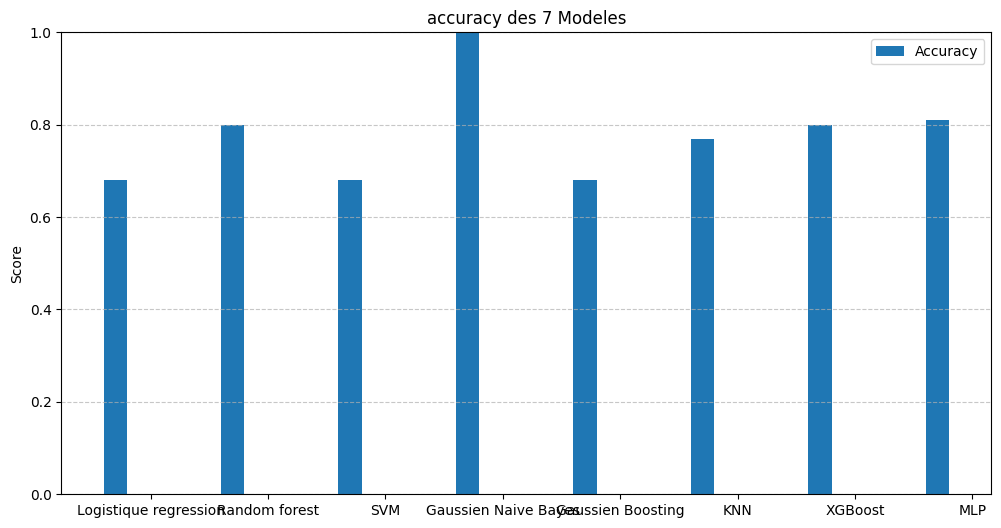

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ["Logistique regression","Random forest","SVM","Gaussien Naive Bayes","Gaussien Boosting","KNN","XGBoost","MLP"]
accuracy = [0.68, 0.80, 0.68 ,29, 0.68, 0.77, 0.80, 0.81]

x = np.arange(len(models))
width = 0.2

# Plot grouped bars
plt.figure(figsize=(12,6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')

# Labels and title
plt.xticks(x, models)
plt.ylabel('Score')
plt.ylim(0,1)
plt.title('accuracy des 7 Modeles')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


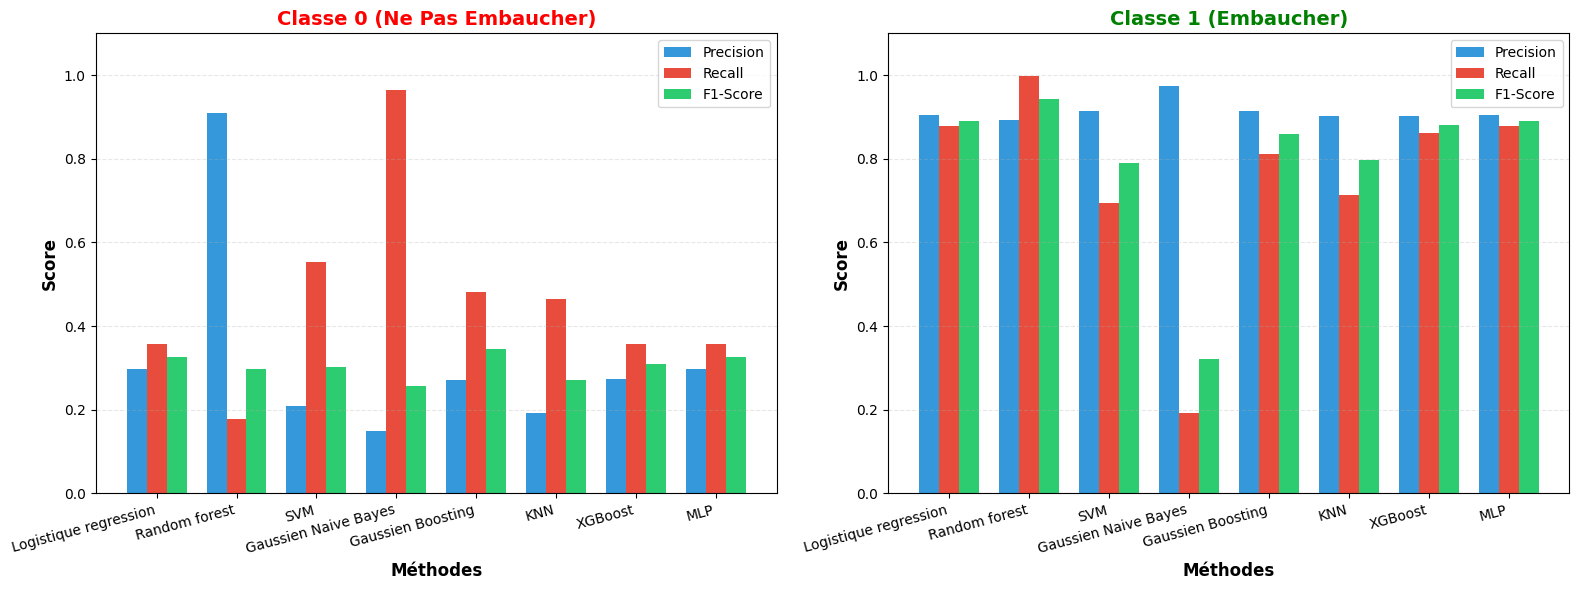

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculer les métriques par classe
methods = ["Logistique regression","Random forest","SVM","Gaussien Naive Bayes","Gaussien Boosting","KNN","XGBoost","MLP"]
predictions = [y_pred, y_pred_rf, y_pred_svm, y_pred_nb,y_pred_gb, y_pred_knn, y_pred_xgb, y_pred_mlp]

# Métriques pour classe 0
precision_class0 = []
recall_class0 = []
f1_class0 = []

# Métriques pour classe 1
precision_class1 = []
recall_class1 = []
f1_class1 = []

for pred in predictions:
    # Classe 0
    precision_class0.append(precision_score(y_test, pred, pos_label=0, zero_division=0))
    recall_class0.append(recall_score(y_test, pred, pos_label=0, zero_division=0))
    f1_class0.append(f1_score(y_test, pred, pos_label=0, zero_division=0))

    # Classe 1
    precision_class1.append(precision_score(y_test, pred, pos_label=1, zero_division=0))
    recall_class1.append(recall_score(y_test, pred, pos_label=1, zero_division=0))
    f1_class1.append(f1_score(y_test, pred, pos_label=1, zero_division=0))

# Créer deux subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(methods))
width = 0.25

# Graphique Classe 0
bars1 = ax1.bar(x - width, precision_class0, width, label='Precision', color='#3498db')
bars2 = ax1.bar(x, recall_class0, width, label='Recall', color='#e74c3c')
bars3 = ax1.bar(x + width, f1_class0, width, label='F1-Score', color='#2ecc71')

ax1.set_xlabel('Méthodes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Classe 0 (Ne Pas Embaucher)', fontsize=14, fontweight='bold', color='red')
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=15, ha='right')
ax1.legend()
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Graphique Classe 1
bars4 = ax2.bar(x - width, precision_class1, width, label='Precision', color='#3498db')
bars5 = ax2.bar(x, recall_class1, width, label='Recall', color='#e74c3c')
bars6 = ax2.bar(x + width, f1_class1, width, label='F1-Score', color='#2ecc71')

ax2.set_xlabel('Méthodes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Classe 1 (Embaucher)', fontsize=14, fontweight='bold', color='green')
ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=15, ha='right')
ax2.legend()
ax2.set_ylim([0, 1.1])
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Liste des modèles et prédictions
modeles = ["Logistique regression","Random forest","SVM","Gaussien Naive Bayes","KNN","Gaussien Boosting","XGBoost","MLP"]
predictions = [y_pred, y_pred_rf, y_pred_svm, y_pred_nb,y_pred_gb, y_pred_knn, y_pred_xgb, y_pred_mlp]

# Créer une liste pour stocker les résultats
resultats = []

for nom_modele, y in zip(modeles, predictions):
    resultats.append({
        'Modèle': nom_modele,
        'Accuracy': accuracy_score(y_test, y),
        'Precision (0)': precision_score(y_test, y, pos_label=0, zero_division=0),
        'Recall (0)': recall_score(y_test, y_pred, pos_label=0, zero_division=0),
        'F1-Score (0)': f1_score(y_test, y, pos_label=0, zero_division=0),
        'Precision (1)': precision_score(y_test, y, pos_label=1, zero_division=0),
        'Recall (1)': recall_score(y_test, y, pos_label=1, zero_division=0),
        'F1-Score (1)': f1_score(y_test, y, pos_label=1, zero_division=0)
    })

# Créer le DataFrame
tableau_comparaison = pd.DataFrame(resultats)

# Arrondir les valeurs
tableau_comparaison = tableau_comparaison.round(3)

tableau_comparaison

,Modèle,Accuracy,Precision (0),Recall (0),F1-Score (0),Precision (1),Recall (1),F1-Score (1)
0,Logistique regression,0.685,0.218,0.571,0.315,0.918,0.701,0.795
1,Random forest,0.893,0.909,0.571,0.299,0.893,0.997,0.942
2,SVM,0.676,0.208,0.571,0.302,0.914,0.694,0.789
3,Gaussien Naive Bayes,0.290,0.148,0.571,0.257,0.974,0.192,0.321
4,KNN,0.769,0.270,0.571,0.346,0.915,0.810,0.860
5,Gaussien Boosting,0.683,0.191,0.571,0.271,0.902,0.714,0.797
6,XGBoost,0.798,0.274,0.571,0.310,0.902,0.862,0.882
7,MLP,0.812,0.299,0.571,0.325,0.904,0.878,0.891
